# 네이버 검색 트렌드 시계열 차트

다이소 뷰티 전체 브랜드(89개)의 검색 트렌드를 시각화한다.  
데이터: `06_analysis/04_search_trend/output/search_trend_all-brand_base_20260225.csv`  
차트 저장: `04_outputs/figures/search_trend/`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# 한글 폰트
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 인라인 출력
%matplotlib inline

In [ ]:
# ── 경로 설정 ──────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent.parent  # Why-pi/
OUTPUT_DIR = PROJECT_ROOT / "06_analysis" / "04_search_trend" / "output"
CHART_DIR = PROJECT_ROOT / "04_outputs" / "figures" / "search_trend"
CHART_DIR.mkdir(parents=True, exist_ok=True)

# 색상 팔레트
COLORS = [
    "#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6",
    "#1ABC9C", "#E67E22", "#34495E", "#E91E63", "#00BCD4",
]

In [3]:
# ── 데이터 로드 ────────────────────────────────────────
csv_path = OUTPUT_DIR / "search_trend_all-brand_base_20260225.csv"
df = pd.read_csv(csv_path)
df["period"] = pd.to_datetime(df["period"])

print(f"행 수: {len(df):,}")
print(f"기간: {df['period'].min().strftime('%Y-%m')} ~ {df['period'].max().strftime('%Y-%m')}")
print(f"브랜드 수: {df['keyword_group'].nunique()}")
df.head()

행 수: 1,253
기간: 2024-01 ~ 2026-01
브랜드 수: 84


,keyword_group,period,ratio,time_unit
0,뉴트로지나,2024-01-01,1.57480,month
1,뉴트로지나,2024-02-01,1.57480,month
2,뉴트로지나,2024-08-01,1.31233,month
3,뉴트로지나,2024-09-01,2.62467,month
4,뉴트로지나,2024-10-01,4.98687,month


## 유틸리티 함수

In [4]:
def plot_brands(
    df: pd.DataFrame,
    brands: list[str],
    title: str,
    filename: str = None,
    figsize: tuple = (14, 6),
    highlight: str = None,
    annotate_peaks: bool = False,
):
    """브랜드 그룹별 시계열 차트 생성"""
    fig, ax = plt.subplots(figsize=figsize)

    for i, brand in enumerate(brands):
        sub = df[df["keyword_group"] == brand].sort_values("period")
        if sub.empty:
            continue

        color = COLORS[i % len(COLORS)]
        lw = 2.5 if brand == highlight else 1.8
        alpha = 1.0 if brand == highlight else 0.8
        zorder = 10 if brand == highlight else 5

        ax.plot(
            sub["period"], sub["ratio"],
            label=brand, color=color,
            linewidth=lw, alpha=alpha, zorder=zorder,
            marker="o", markersize=3,
        )

        if annotate_peaks:
            peak_idx = sub["ratio"].idxmax()
            peak_row = sub.loc[peak_idx]
            ax.annotate(
                f'{peak_row["ratio"]:.0f}',
                xy=(peak_row["period"], peak_row["ratio"]),
                xytext=(0, 8), textcoords="offset points",
                fontsize=8, ha="center", color=color, fontweight="bold",
            )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("검색 트렌드 (ratio)", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha="right")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xlim(
        df["period"].min() - pd.Timedelta(days=15),
        df["period"].max() + pd.Timedelta(days=15),
    )
    plt.tight_layout()

    if filename:
        path = CHART_DIR / filename
        fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"  저장: {path.name}")

    plt.show()


def plot_heatmap(
    df: pd.DataFrame,
    brands: list[str],
    title: str,
    filename: str = None,
):
    """브랜드×월 히트맵"""
    existing = [b for b in brands if b in df["keyword_group"].unique()]
    sub = df[df["keyword_group"].isin(existing)].copy()
    pivot = sub.pivot_table(
        index="keyword_group", columns="period", values="ratio", aggfunc="first"
    )
    pivot = pivot.reindex(existing)

    fig, ax = plt.subplots(figsize=(16, max(4, len(existing) * 0.45)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")

    ax.set_yticks(range(len(existing)))
    ax.set_yticklabels(existing, fontsize=9)

    periods = [p.strftime("%Y-%m") for p in pivot.columns]
    ax.set_xticks(range(len(periods)))
    ax.set_xticklabels(periods, rotation=45, ha="right", fontsize=8)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                color = "white" if val > 50 else "black"
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6, color=color)

    plt.colorbar(im, ax=ax, shrink=0.8, label="ratio")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()

    if filename:
        path = CHART_DIR / filename
        fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"  저장: {path.name}")

    plt.show()

---

## 0. 다이소 뷰티 시장 확대 추이

검색 트렌드에 잡히는 브랜드 수가 **2024-01의 32개에서 2025-12의 68개로 2배 이상 증가**.  
다이소 뷰티 시장 자체가 확대되고 있음을 보여준다.

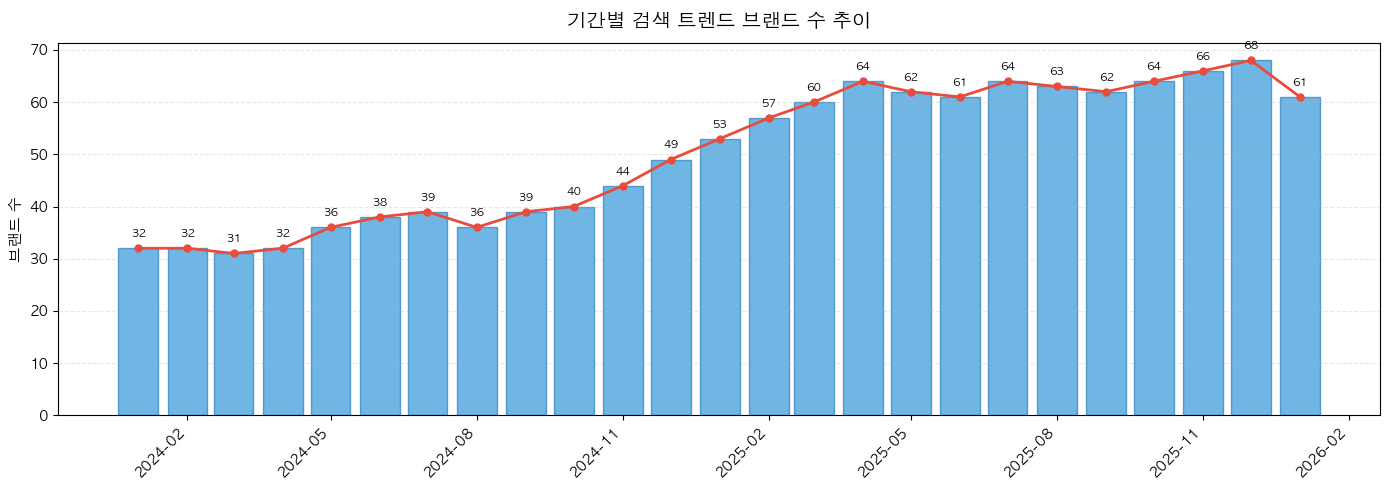

In [5]:
# 기간별 브랜드 수 추이
counts = df.groupby("period")["keyword_group"].nunique().reset_index()
counts.columns = ["period", "brand_count"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(counts["period"], counts["brand_count"], width=25, color="#3498DB", alpha=0.7, edgecolor="#2980B9")
ax.plot(counts["period"], counts["brand_count"], color="#E74C3C", linewidth=2, marker="o", markersize=5)

for _, row in counts.iterrows():
    ax.annotate(
        str(int(row["brand_count"])),
        xy=(row["period"], row["brand_count"]),
        xytext=(0, 8), textcoords="offset points",
        fontsize=8, ha="center", fontweight="bold",
    )

ax.set_title("기간별 검색 트렌드 브랜드 수 추이", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("브랜드 수", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.tight_layout()

fig.savefig(CHART_DIR / "00_brand_count_timeline.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

---

## 1. 전체 TOP 5 비교

| 순위 | 브랜드 | 평균 ratio | 패턴 유형 |
|------|--------|-----------|----------|
| 1 | 바세린 | 54.76 | 계절형 |
| 2 | 마데카21 | 47.28 | 안정형 |
| 3 | 파티온 | 56.50 | 바이럴형 |
| 4 | 손앤박 | 24.22 | 바이럴형 |
| 5 | AHC | 30.29 | 신규 진입 |

  저장: 01_top5_overall.png


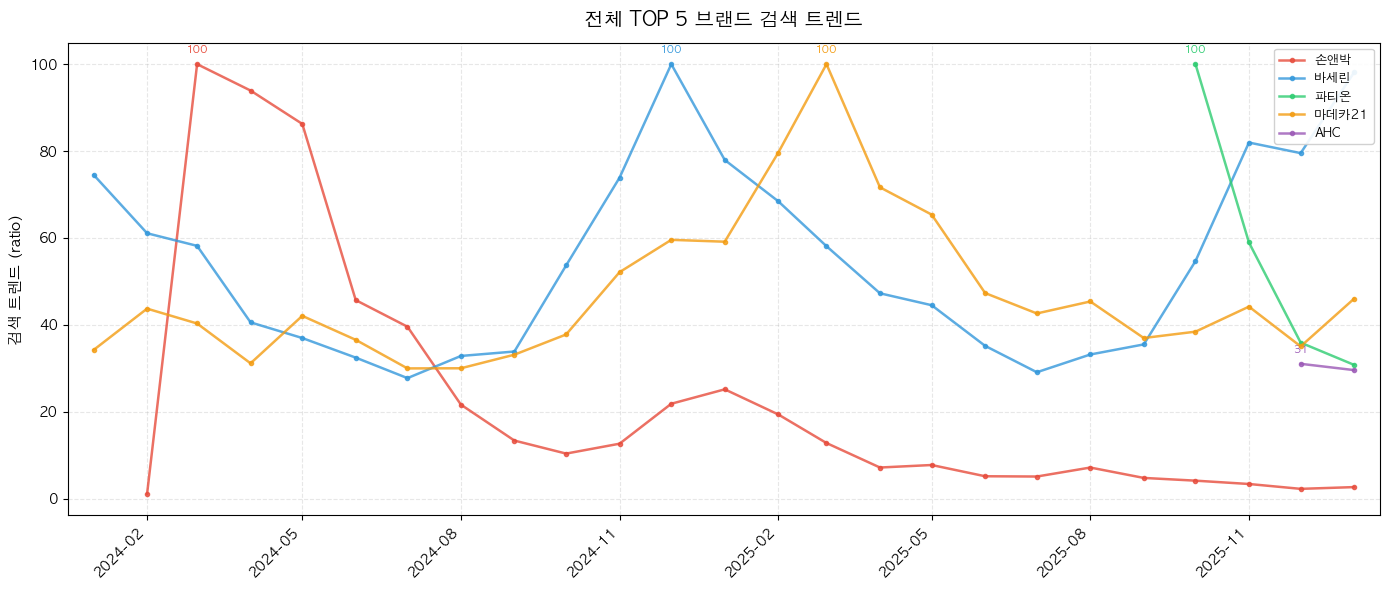

In [6]:
plot_brands(
    df,
    ["손앤박", "바세린", "파티온", "마데카21", "AHC"],
    "전체 TOP 5 브랜드 검색 트렌드",
    filename="01_top5_overall.png",
    annotate_peaks=True,
)

---

## 2. 바이럴형 브랜드 — 급등 후 급락

바이럴의 반감기는 매우 짧다. 피크 후 3개월 내 ratio가 절반 이하, 6개월 후 10 이하로 급락.

| 브랜드 | 피크 시기 | 2026-01 | 하락률 |
|--------|----------|---------|-------|
| 손앤박 | 2024-02 | 2.63 | -97.4% |
| 메디필 | 2024-05 | 10.99 | -89.0% |
| 쿤달 | 2024-05 | 4.50 | -95.5% |
| 코시에로 | 2025-07 | 8.74 | -91.3% |
| 파넬 | 2025-07 | 3.05 | -97.0% |
| 코드글로컬러 | 2025-03 | 0.70 | -99.3% |

  저장: 02_viral_brands.png


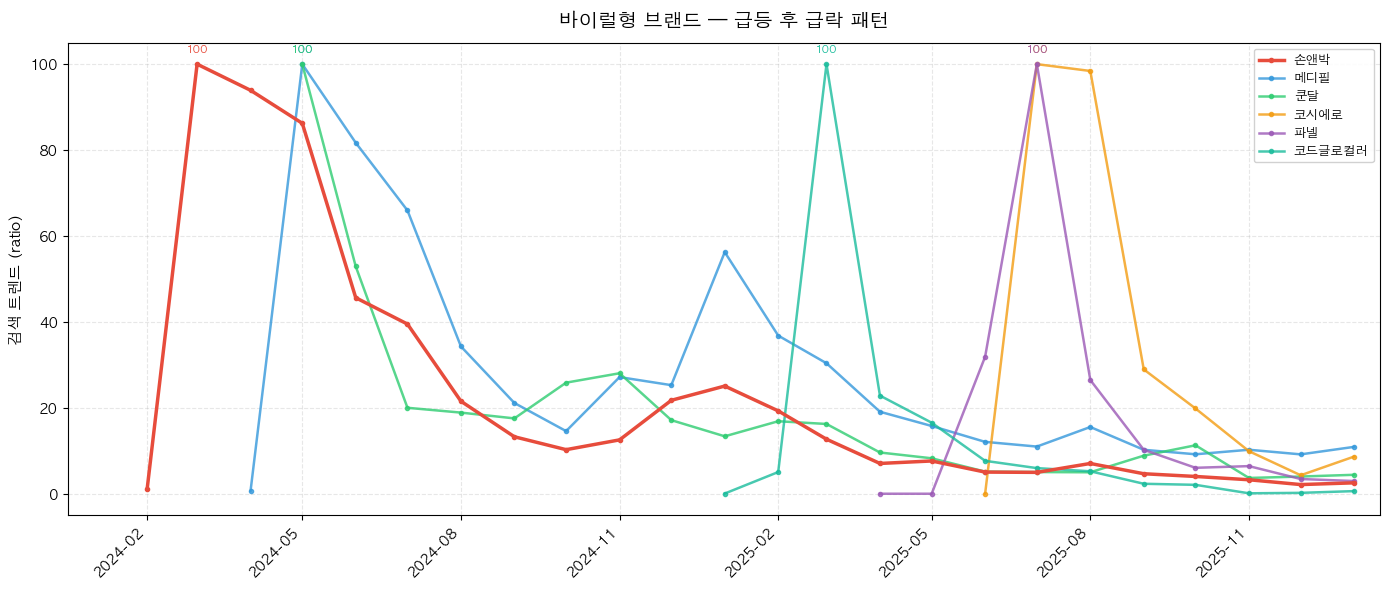

In [7]:
plot_brands(
    df,
    ["손앤박", "메디필", "쿤달", "코시에로", "파넬", "코드글로컬러"],
    "바이럴형 브랜드 — 급등 후 급락 패턴",
    filename="02_viral_brands.png",
    highlight="손앤박",
    annotate_peaks=True,
)

---

## 3. 안정형 브랜드 — 꾸준한 검색 수요

변동성(std)이 낮으면서 평균 ratio가 높은 브랜드. 연착륙 상품의 검색 트렌드 버전.

| 브랜드 | 평균 ratio | std | ratio 범위 |
|--------|-----------|-----|----------|
| 바세린 | 54.76 | 19.14 | 28~100 (계절) |
| 마데카21 | 47.28 | 17.03 | 31~100 |
| 김정문알로에 | 40.55 | 11.84 | 19~67 |
| 닥터오라클 | 38.05 | 22.55 | 0~100 |
| 본셉 | 14.58 | 8.76 | 4~45 |

  저장: 03_stable_brands.png


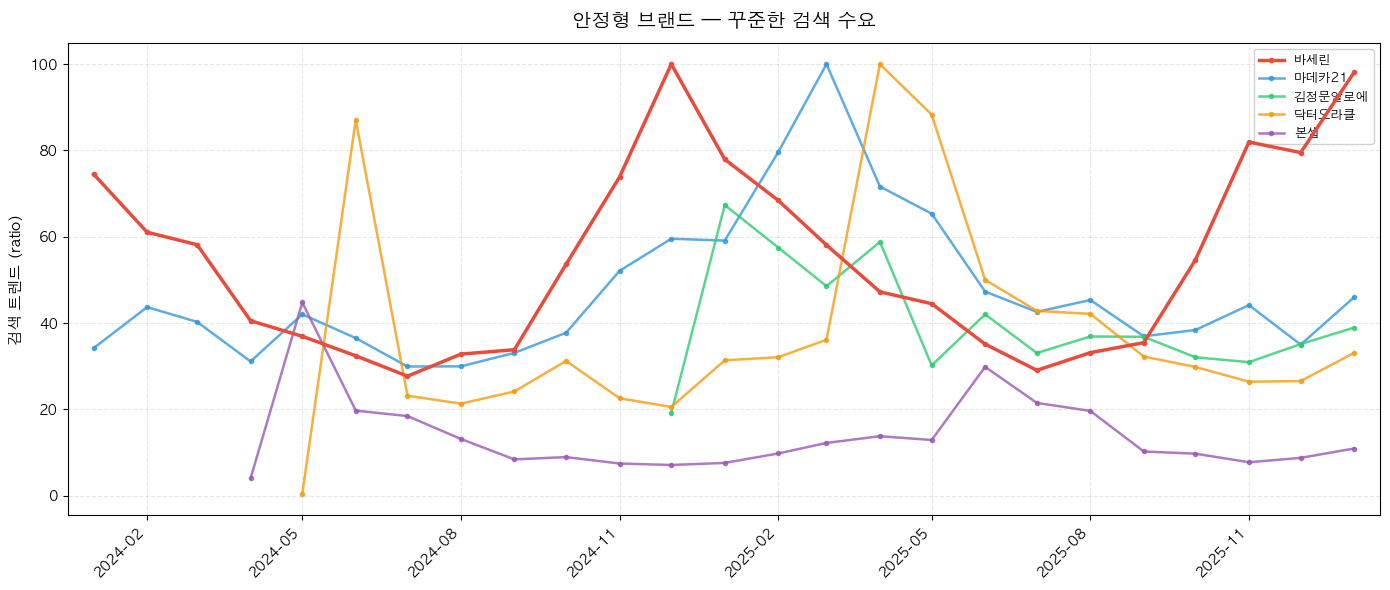

In [8]:
plot_brands(
    df,
    ["바세린", "마데카21", "김정문알로에", "닥터오라클", "본셉"],
    "안정형 브랜드 — 꾸준한 검색 수요",
    filename="03_stable_brands.png",
    highlight="바세린",
)

---

## 4. 성장세 브랜드 — 최근 상승

| 브랜드 | 데이터 시작 | 최근 (2026-01) | 추세 |
|--------|-----------|--------------|------|
| 파티온 | 2025-10 | 31.31 | 급등 후 하락 중 |
| 더랩 바이 블랑두 | 2024-10 | 76.97 | **지속 성장** |
| 그로우어스 | 2024-01 | 14.24 | 피크 후 하락 |
| AHC | 2025-12 | 29.56 | 신규 |
| 이즈앤트리 | 2025-11 | 5.21 | 신규 |

  저장: 04_growing_brands.png


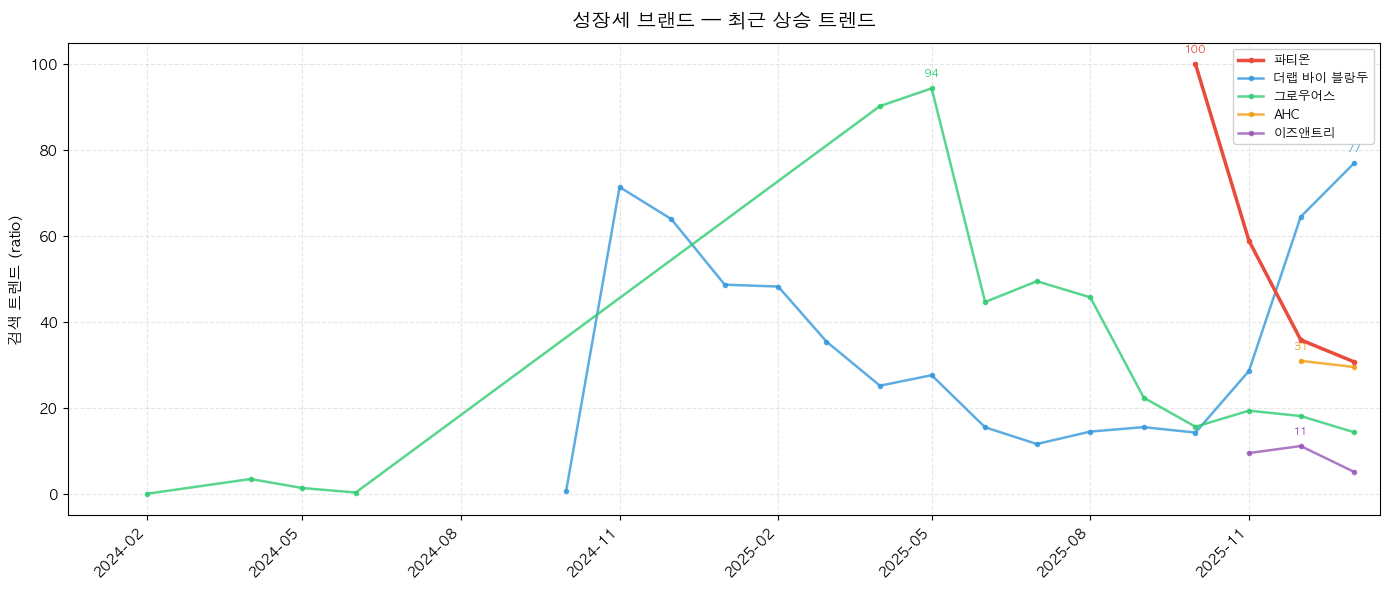

In [9]:
plot_brands(
    df,
    ["파티온", "더랩 바이 블랑두", "그로우어스", "AHC", "이즈앤트리"],
    "성장세 브랜드 — 최근 상승 트렌드",
    filename="04_growing_brands.png",
    highlight="파티온",
    annotate_peaks=True,
)

---

## 5. 계절성 패턴 — 겨울 보습 vs 봄 기능성

바세린의 겨울/여름 ratio 비율은 약 **3:1**로 매우 뚜렷하다.

| 브랜드 | 겨울 평균 | 여름 평균 | 진폭 |
|--------|----------|----------|------|
| 바세린 | ~85 | ~32 | ~53 |
| 더랩 바이 블랑두 | ~70 | ~14 | ~56 |
| 김정문알로에 | ~50 | ~35 | ~15 |
| 마데카21 | ~45 | ~32 | ~13 |

  저장: 05_seasonal_pattern.png


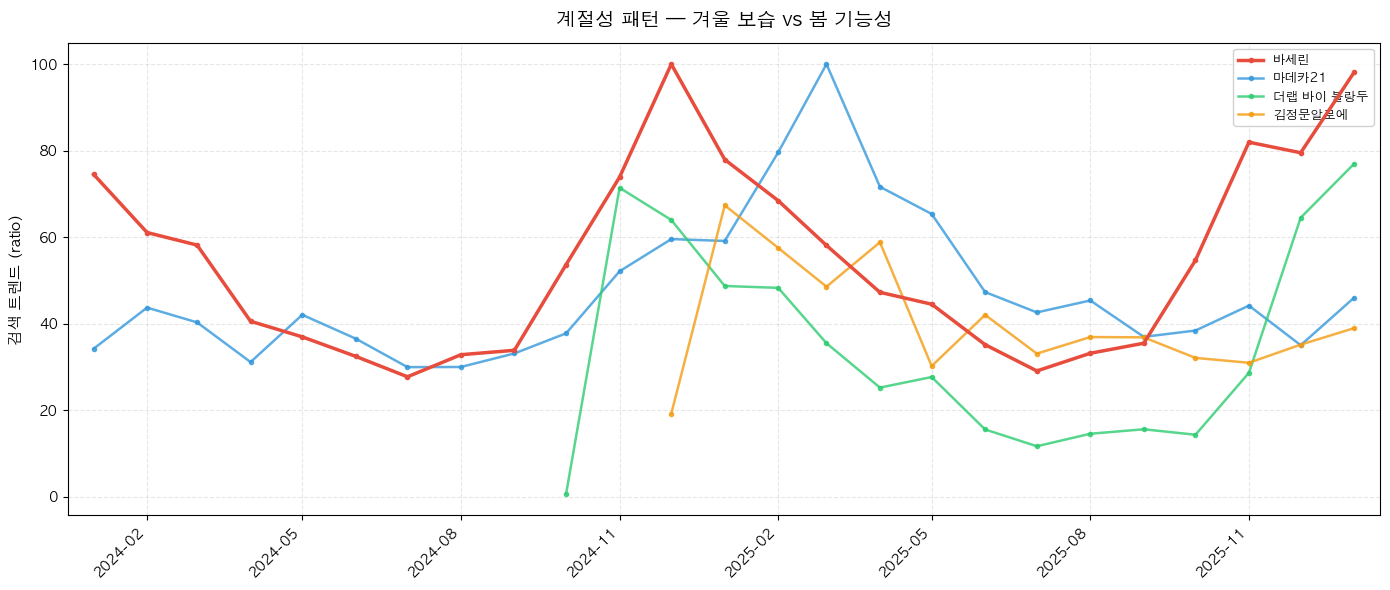

In [10]:
plot_brands(
    df,
    ["바세린", "마데카21", "더랩 바이 블랑두", "김정문알로에"],
    "계절성 패턴 — 겨울 보습 vs 봄 기능성",
    filename="05_seasonal_pattern.png",
    highlight="바세린",
)

### 바세린 월별 ratio 상세

```
2024: 75→61→58→41→37→32→28→33→34→54→74→100
2025: 78→68→58→47→45→35→29→33→35→55→82→80
2026: 98
       ↑                        ↑
     겨울 피크(100)         여름 저점(28~29)
```

> 10월부터 재고를 확보하고, 4월부터 축소하는 시즌 운영이 최적이다.

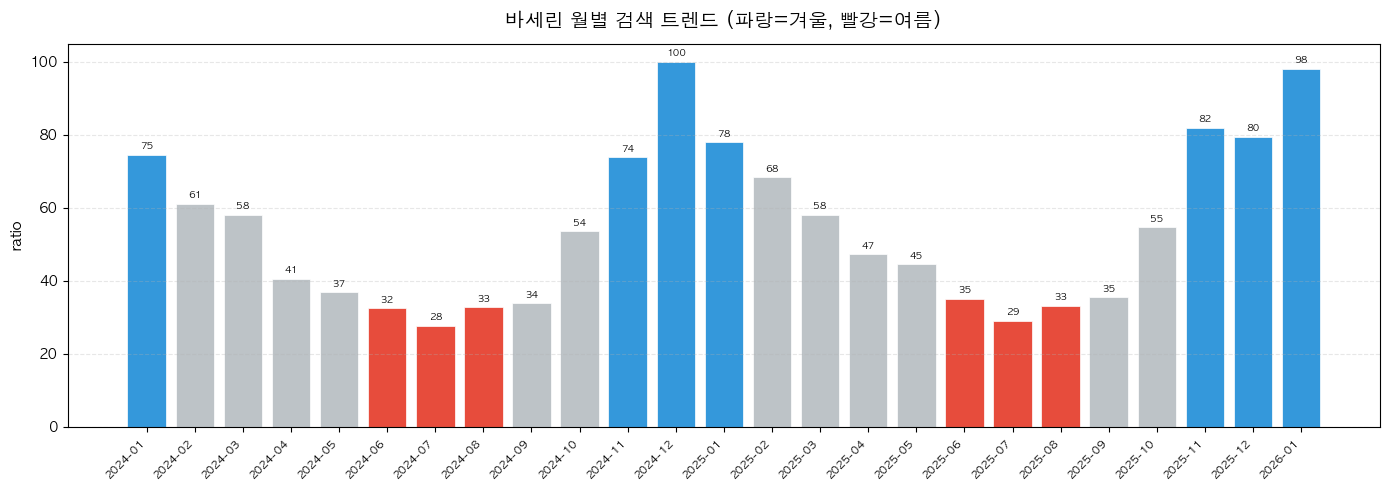

In [11]:
# 바세린 월별 ratio 상세 바 차트
vaseline = df[df["keyword_group"] == "바세린"].sort_values("period").copy()
vaseline["month_label"] = vaseline["period"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(14, 5))

# 겨울(11,12,1) vs 여름(6,7,8) 색상 구분
colors = []
for m in vaseline["period"].dt.month:
    if m in [11, 12, 1]:
        colors.append("#3498DB")  # 겨울 파랑
    elif m in [6, 7, 8]:
        colors.append("#E74C3C")  # 여름 빨강
    else:
        colors.append("#BDC3C7")  # 기타 회색

ax.bar(range(len(vaseline)), vaseline["ratio"], color=colors, edgecolor="white", linewidth=0.5)

for i, (_, row) in enumerate(vaseline.iterrows()):
    ax.text(i, row["ratio"] + 1.5, f"{row['ratio']:.0f}", ha="center", fontsize=7, fontweight="bold")

ax.set_xticks(range(len(vaseline)))
ax.set_xticklabels(vaseline["month_label"], rotation=45, ha="right", fontsize=8)
ax.set_title("바세린 월별 검색 트렌드 (파랑=겨울, 빨강=여름)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("ratio", fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.tight_layout()
plt.show()

---

## 6. Z세대(10~20대) 인기 브랜드

Z세대 브랜드는 **바이럴 주기가 더 짧다**. 파티온·그로우어스 모두 피크 후 빠르게 하락.

  저장: 06_gen_z_brands.png


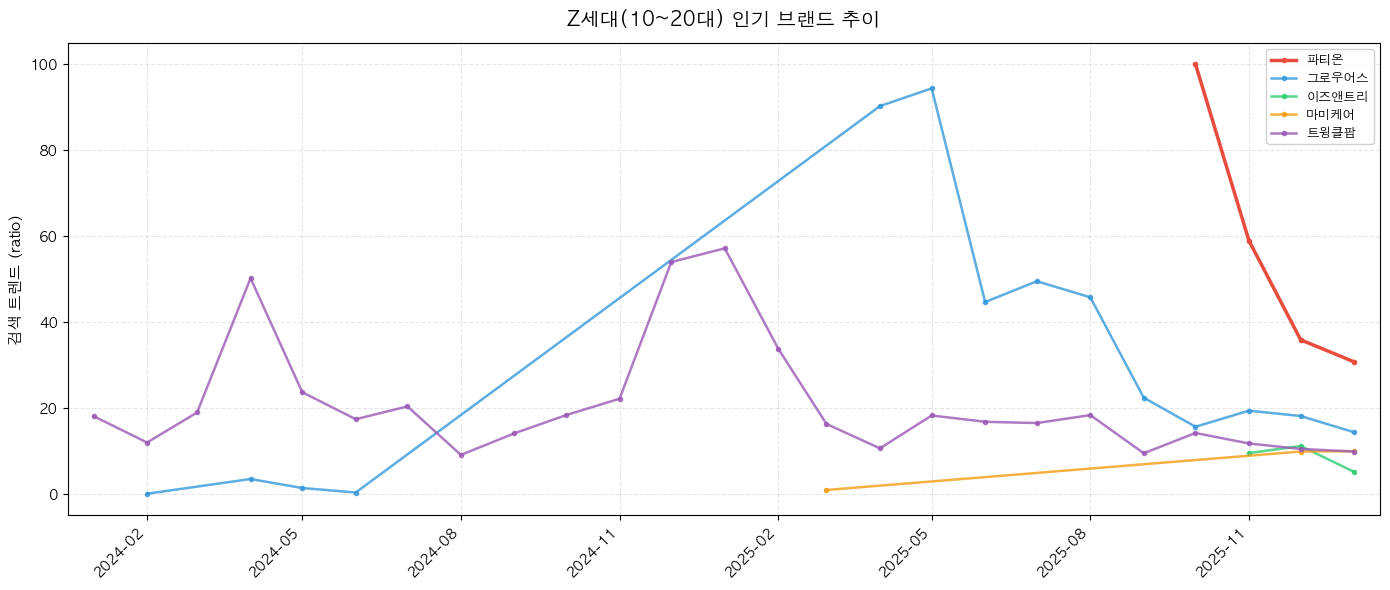

In [12]:
plot_brands(
    df,
    ["파티온", "그로우어스", "이즈앤트리", "마미케어", "트윙클팝"],
    "Z세대(10~20대) 인기 브랜드 추이",
    filename="06_gen_z_brands.png",
    highlight="파티온",
)

---

## 7. 시니어(50~60대) 인기 브랜드

시니어 브랜드는 Z세대와 대조적으로 **변동성이 낮고 오래 유지**된다.

  저장: 07_senior_brands.png


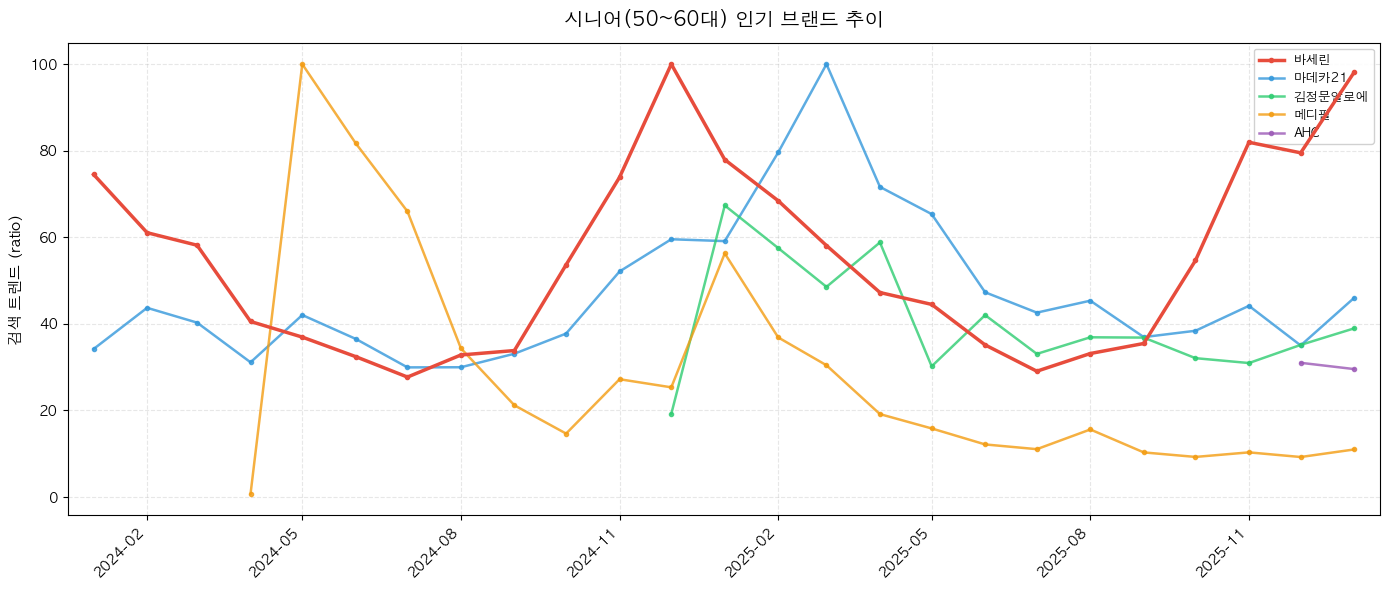

In [13]:
plot_brands(
    df,
    ["바세린", "마데카21", "김정문알로에", "메디필", "AHC"],
    "시니어(50~60대) 인기 브랜드 추이",
    filename="07_senior_brands.png",
    highlight="바세린",
)

---

## 8. 하락 추세 브랜드

재고 심도를 축소하고, Hub 매장에서 Spoke로 이동시키는 전략 필요.

| 브랜드 | 초기 ratio | 2026-01 | 하락률 |
|--------|-----------|---------|-------|
| VT | 63.35 | 19.32 | -69.5% |
| 트윙클팝 | 57.16 | 9.91 | -82.7% |
| 닥터씨피유 | 29.52 | 7.41 | -74.9% |
| 큐어레스트 | 21.17 | 7.09 | -66.5% |
| 드롭비 | 10.62 | 1.92 | -81.9% |

  저장: 08_declining_brands.png


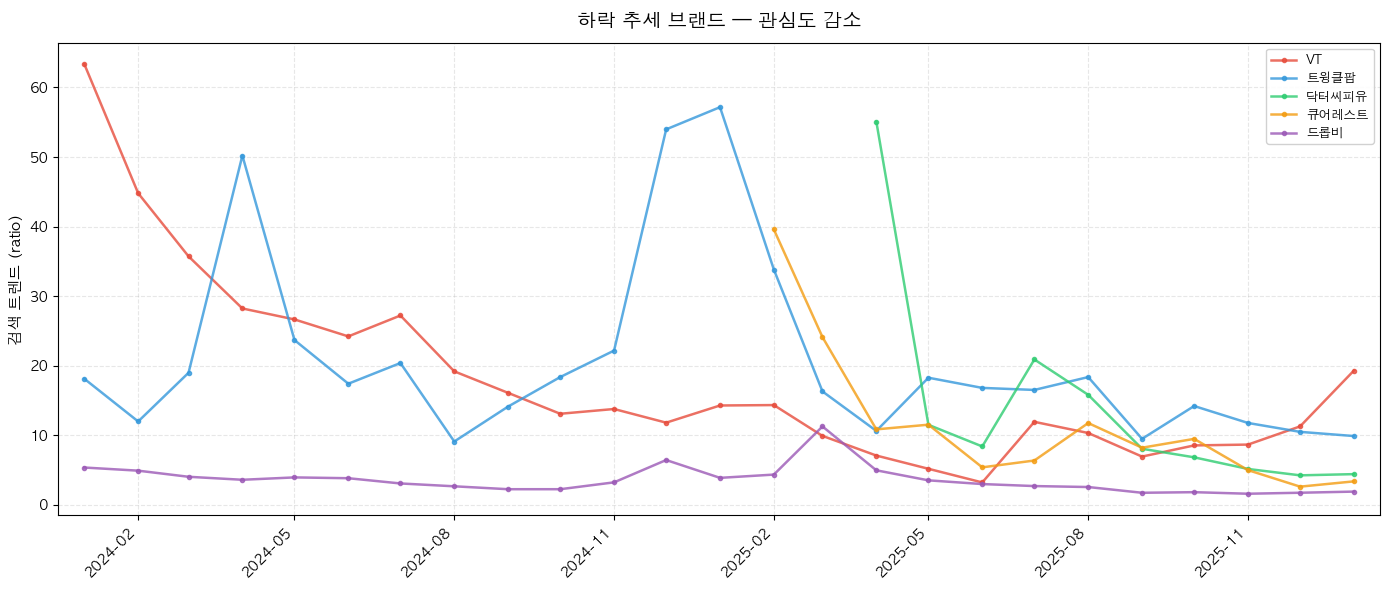

In [14]:
plot_brands(
    df,
    ["VT", "트윙클팝", "닥터씨피유", "큐어레스트", "드롭비"],
    "하락 추세 브랜드 — 관심도 감소",
    filename="08_declining_brands.png",
)

---

## 9. 중위권 경쟁 브랜드

코시에로·파넬은 2025년 여름에 동시 피크를 형성 — 여름 스킨케어 시즌 효과.

  저장: 09_midtier_brands.png


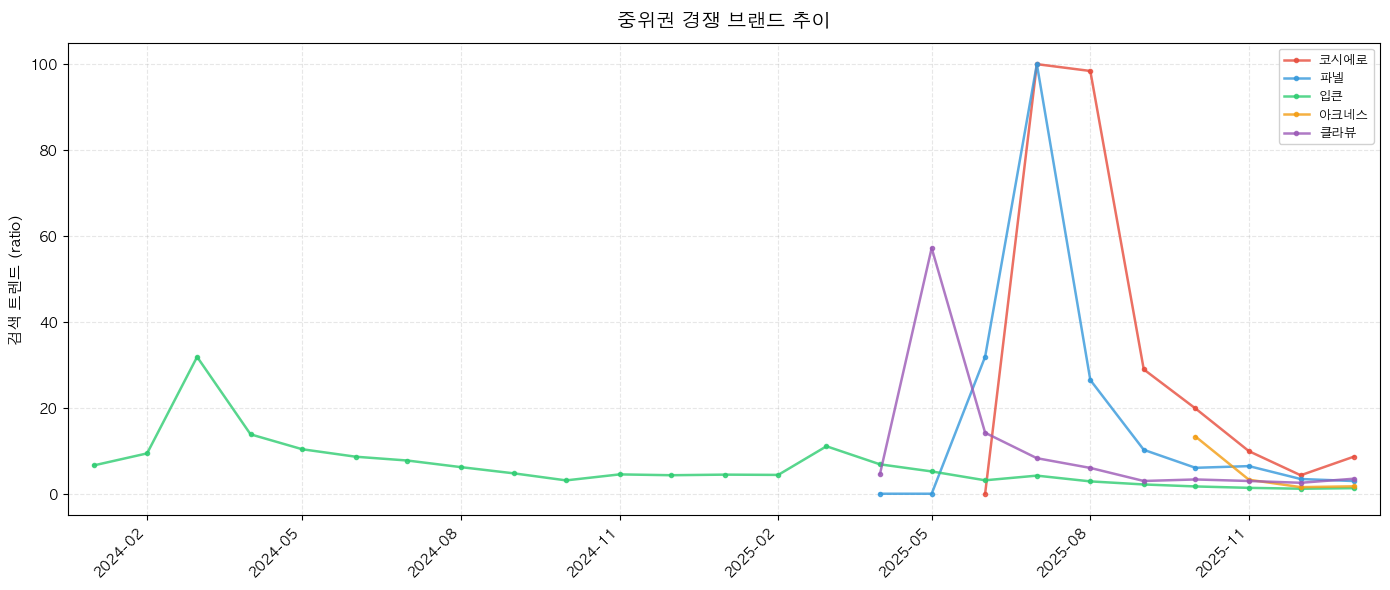

In [15]:
plot_brands(
    df,
    ["코시에로", "파넬", "입큰", "아크네스", "클라뷰"],
    "중위권 경쟁 브랜드 추이",
    filename="09_midtier_brands.png",
)

---

## 10. TOP 15 히트맵 (월별 검색량)

| 패턴 | 브랜드 | 히트맵 특징 |
|------|--------|----------|
| 단기 집중형 | 손앤박, 메디필, 코시에로 | 특정 2~3개월만 진한 색 |
| 계절 반복형 | 바세린, 더랩 바이 블랑두 | 겨울마다 진한 색 반복 |
| 장기 안정형 | 마데카21, 김정문알로에 | 전 기간 중간 톤 유지 |
| 최근 등장형 | 파티온, AHC, 이즈앤트리 | 우측 끝에만 색 |
| 우하향형 | 입큰, 본셉 | 좌측 진하고 우측 연해짐 |

  저장: 10_top15_heatmap.png


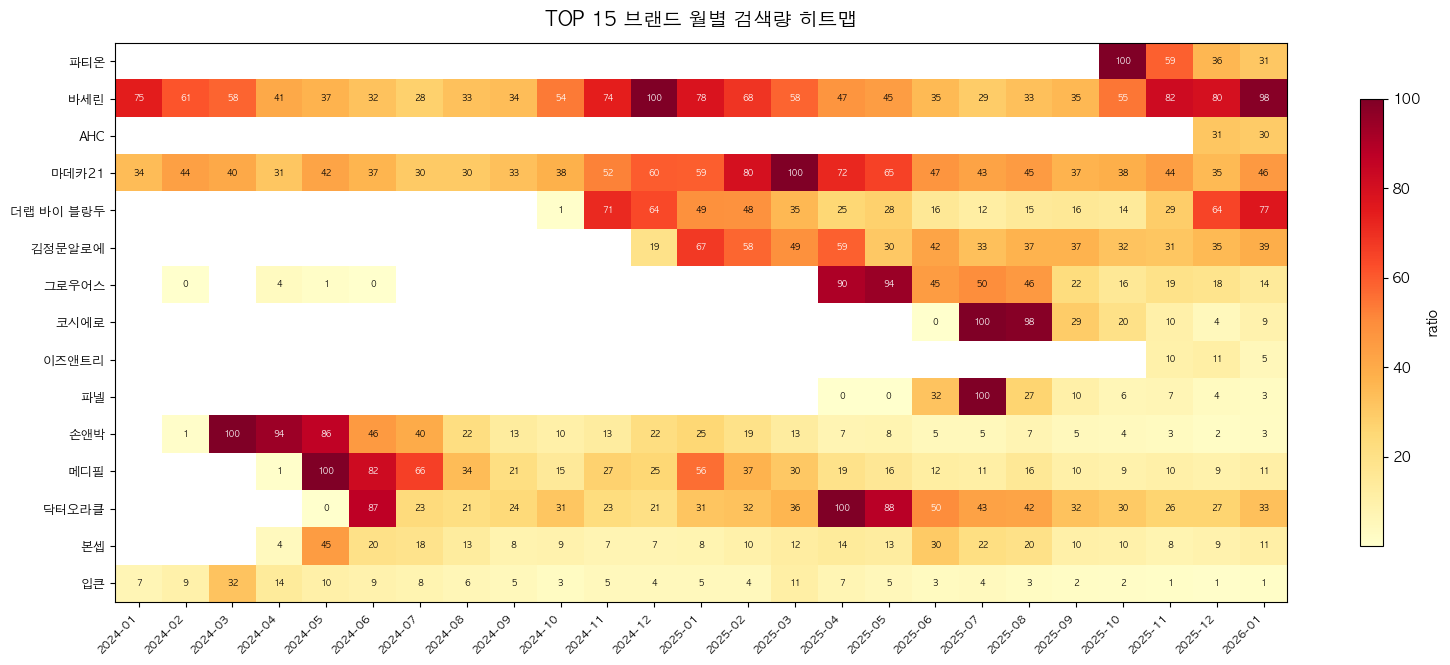

In [16]:
top15 = [
    "파티온", "바세린", "AHC", "마데카21", "더랩 바이 블랑두",
    "김정문알로에", "그로우어스", "코시에로", "이즈앤트리", "파넬",
    "손앤박", "메디필", "닥터오라클", "본셉", "입큰",
]

plot_heatmap(
    df, top15,
    "TOP 15 브랜드 월별 검색량 히트맵",
    filename="10_top15_heatmap.png",
)

---

## 11. 브랜드 수명주기 분류 요약

| 수명주기 | 브랜드 수 | 대표 브랜드 | 재고 전략 |
|---------|----------|-----------|----------|
| 바이럴형 | ~15개 | 손앤박, 메디필, 쿤달, 코시에로, 파넬, 파티온 | 입점 3개월 집중 → 빠른 축소 |
| 계절형 | ~8개 | 바세린, 더랩 바이 블랑두 | 시즌 2개월 전 확보, 비수기 축소 |
| 안정형 | ~20개 | 마데카21, 김정문알로에, 닥터오라클, 본셉 | Hub 매장 상시 재고 유지 |
| 하락형 | ~40개 | VT, 트윙클팝, 드롭비, 큐어레스트 | 재고 심도 축소, Spoke로 이동 |

In [17]:
# 브랜드별 요약 통계 (평균 ratio 상위 30개)
summary = (
    df.groupby("keyword_group")["ratio"]
    .agg(["mean", "max", "min", "std", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)
summary.columns = ["평균", "최대", "최소", "표준편차", "데이터수"]
summary.head(30)

,평균,최대,최소,표준편차,데이터수
keyword_group,,,,,
펠트,66.12,90.09,41.63,13.63,25
파티온,56.40,100.00,30.76,31.55,4
바세린,54.76,100.00,27.72,21.92,25
데일리콤마,49.05,100.00,20.14,21.14,25
마데카21,47.28,100.00,29.95,17.03,25
김정문알로에,40.55,67.35,19.22,13.15,14
닥터오라클,38.18,100.00,0.48,24.62,21
도루코,35.96,100.00,1.31,24.62,25
더랩 바이 블랑두,35.20,76.97,0.68,24.05,16


In [18]:
print(f"차트 저장 완료: {CHART_DIR}")
print(f"생성된 차트: {len(list(CHART_DIR.glob('*.png')))}개")
for p in sorted(CHART_DIR.glob("*.png")):
    print(f"  {p.name}")

차트 저장 완료: /Users/yu_seok/Documents/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/07_docs/search_trend/charts
생성된 차트: 11개
  00_brand_count_timeline.png
  01_top5_overall.png
  02_viral_brands.png
  03_stable_brands.png
  04_growing_brands.png
  05_seasonal_pattern.png
  06_gen_z_brands.png
  07_senior_brands.png
  08_declining_brands.png
  09_midtier_brands.png
  10_top15_heatmap.png
